<a href="https://colab.research.google.com/github/Krishishah7/nlp-learning-series/blob/main/02_similarity/similarity_score_distribution_and_heatmap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Similarity Score Distribution and Heatmap

## Objective
This notebook visualizes cosine similarity scores between sentence embeddings
to understand their overall distribution and semantic structure.

The goal is to build global intuition about similarity overlap,
clusters, and semantic neighborhoods.

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
model = SentenceTransformer("all-MiniLM-L6-v2")

In [ ]:
sentences = [
    "I love machine learning",
    "I enjoy studying machine learning",
    "Natural language processing is fascinating",
    "Transformers generate embeddings",
    "Sentence embeddings help semantic search",
    "The weather is very hot today",
    "He plays football every weekend",
    "Python is a programming language"
]

In [7]:
embeddings = model.encode(sentences)
similarity_matrix = cosine_similarity(embeddings)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=sentences,
    columns=sentences
)

similarity_df

,I love machine learning,I enjoy studying machine learning,Natural language processing is fascinating,Transformers generate embeddings,Sentence embeddings help semantic search,The weather is very hot today,He plays football every weekend,Python is a programming language
I love machine learning,1.000000,0.782422,0.505262,0.165077,0.205293,0.024017,0.079104,0.235739
I enjoy studying machine learning,0.782422,1.000000,0.398565,0.100224,0.138439,-0.019360,0.132795,0.300504
Natural language processing is fascinating,0.505262,0.398565,1.000000,0.220526,0.400441,0.059256,0.010954,0.229422
Transformers generate embeddings,0.165077,0.100224,0.220526,1.000000,0.363793,-0.025378,0.013166,-0.007598
Sentence embeddings help semantic search,0.205293,0.138439,0.400441,0.363793,1.000000,-0.019572,0.007021,0.067269
The weather is very hot today,0.024017,-0.019360,0.059256,-0.025378,-0.019572,1.000000,0.092898,0.067483
He plays football every weekend,0.079104,0.132795,0.010954,0.013166,0.007021,0.092898,1.000000,0.041379
Python is a programming language,0.235739,0.300504,0.229422,-0.007598,0.067269,0.067483,0.041379,1.000000


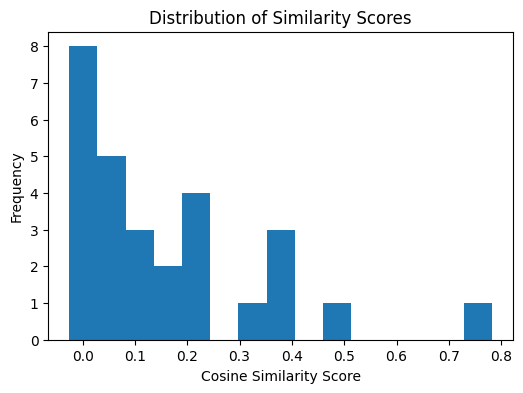

In [8]:
scores = similarity_matrix[np.triu_indices(len(sentences), k=1)]

plt.figure(figsize=(6,4))
plt.hist(scores, bins=15)
plt.xlabel("Cosine Similarity Score")
plt.ylabel("Frequency")
plt.title("Distribution of Similarity Scores")
plt.show()

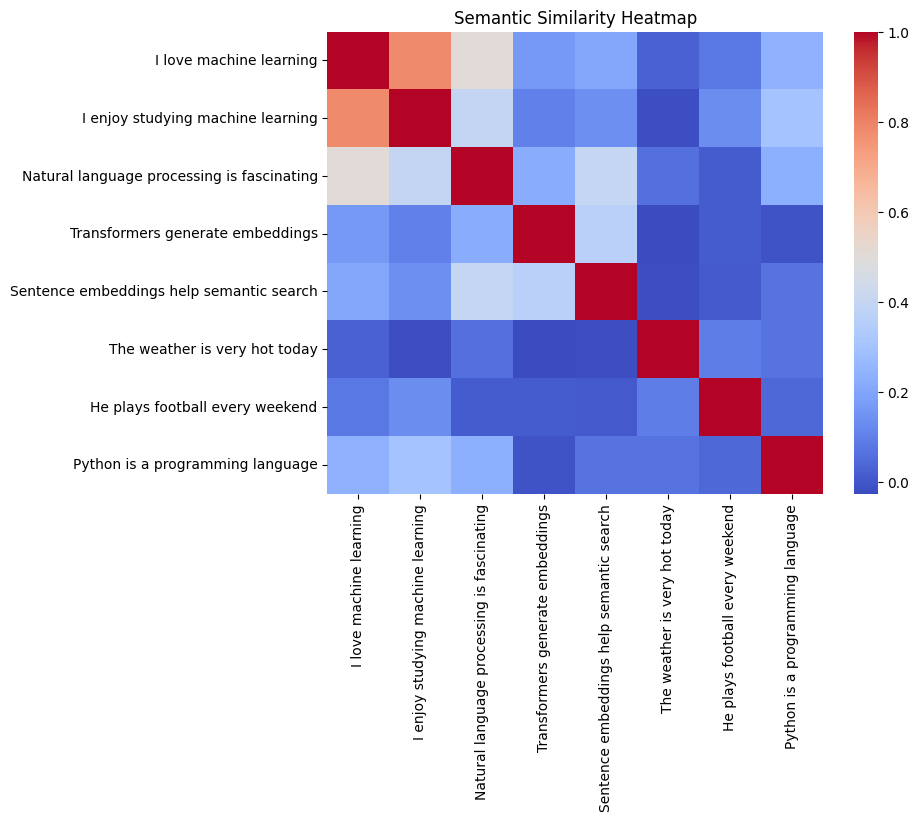

In [9]:
plt.figure(figsize=(8,6))
sns.heatmap(similarity_df, cmap="coolwarm", annot=False)
plt.title("Semantic Similarity Heatmap")
plt.show()

## Observations

- Similarity scores form overlapping ranges rather than clean separations
- Semantically related sentences form visible clusters
- Unrelated sentences show consistently low similarity
- Overlap explains why hard thresholds fail in practice

## Key Insight
Visualizing similarity makes it clear that semantic similarity
is continuous, not binary.